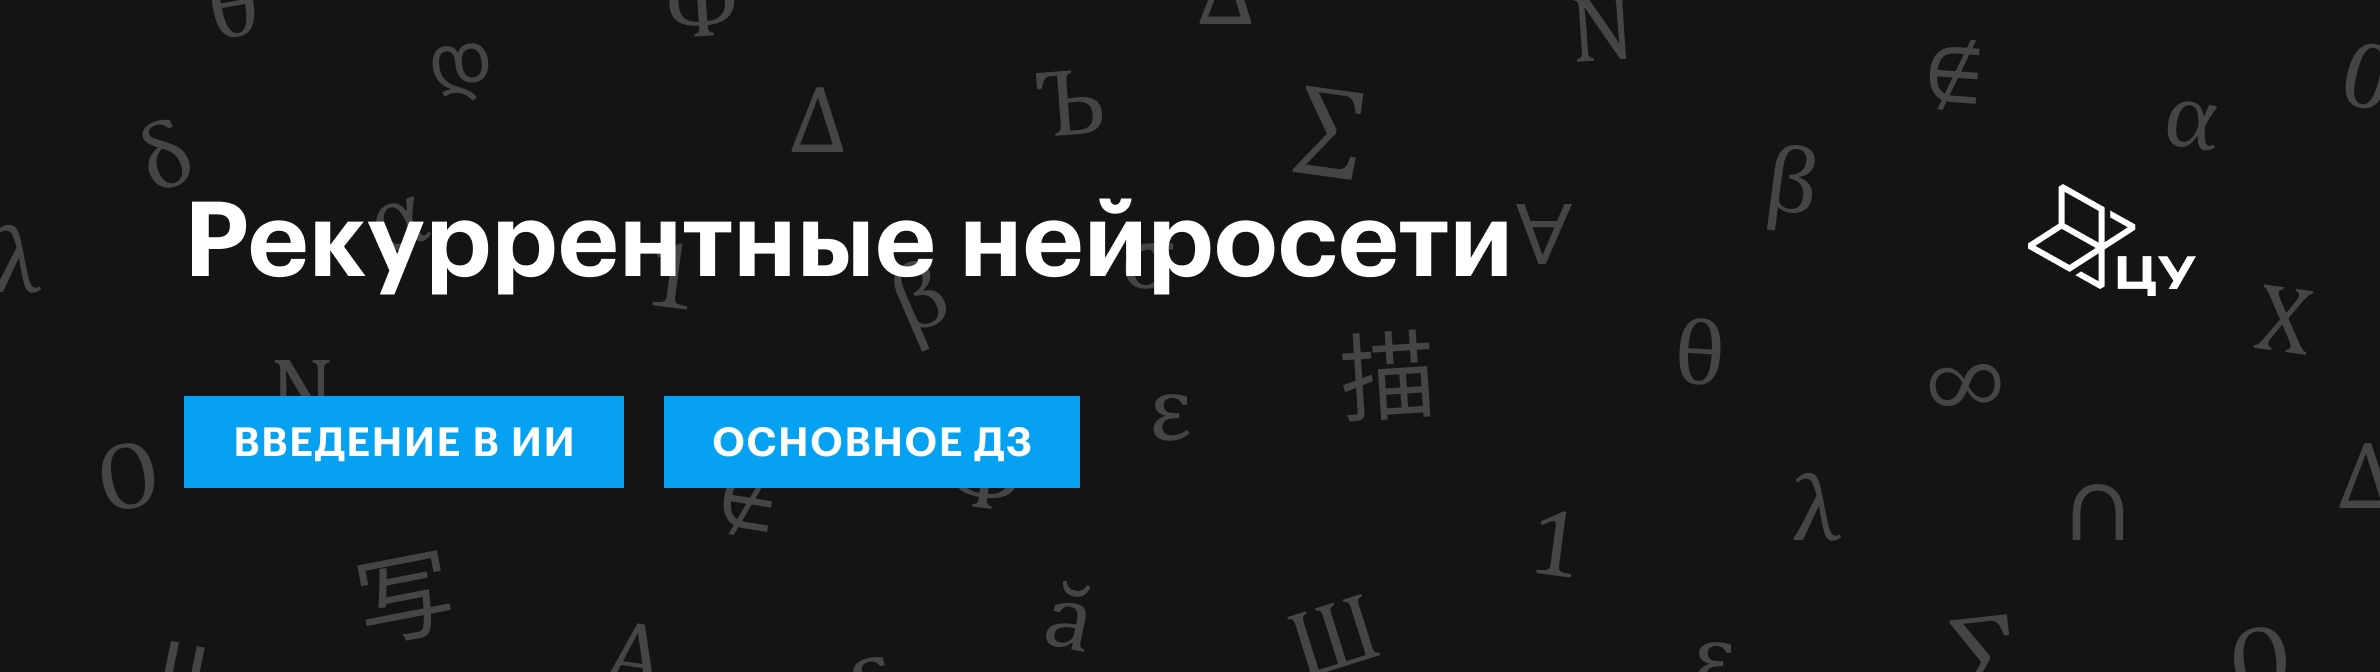

# Домашнее задание по теме «Рекуррентные нейронные сети»

В этом домашнем задании ты познакомишься со стандартными нейросетевыми блоками для рекуррентной обработки последовательностей: RNN, LSTM и GRU.

Задание будет состоять из двух частей.

В части 1 ты попробуешь использовать RNN, LSTM и GRU для задачи предсказания следующего значения временного ряда (мы разбирали это на семинаре).

В части 2 — сравнишь, как RNN, LSTM и GRU справляются с запоминанием контекста в скрытом состоянии.

>**Важно.** Вторая часть задания будет строиться вокруг несложной алгоритмической задачи, которую можно решить и без рекуррентной нейросети. На ней удобно будет показать различия между основными рекуррентными блоками, но с практической точки зрения учить нейросеть под такую задачу бессмысленно. Поэтому если она попадётся тебе на собеседовании, не предлагай использовать нейросеть (или не говори, что ты из ЦУ).

>### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.

## Импорт пакетов

In [ ]:
# Импортируем необходимые пакеты
from time import time

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

## Часть 1. Применение RNN, LSTM, GRU

Напиши три нейросети, которые будут решать задачу предсказания временного ряда. Мы разбирали это на семинаре, но там задача решалась с помощью самописной RNN, а сейчас тебе нужно использовать блоки основных типов рекуррентных нейросетей, реализованных в PyTorch. Ознакомься с документацией на них и обучи модели.

Документация:
- [RNN](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html);
- [LSTM](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html);
- [GRU](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html).

Ниже приведён код для генерации синтетических данных и обучения моделей, идентичный коду с семинара. После него следует часть, где тебе нужно будет задать свои рекуррентные нейросети для обучения.

Код для генерации данных:

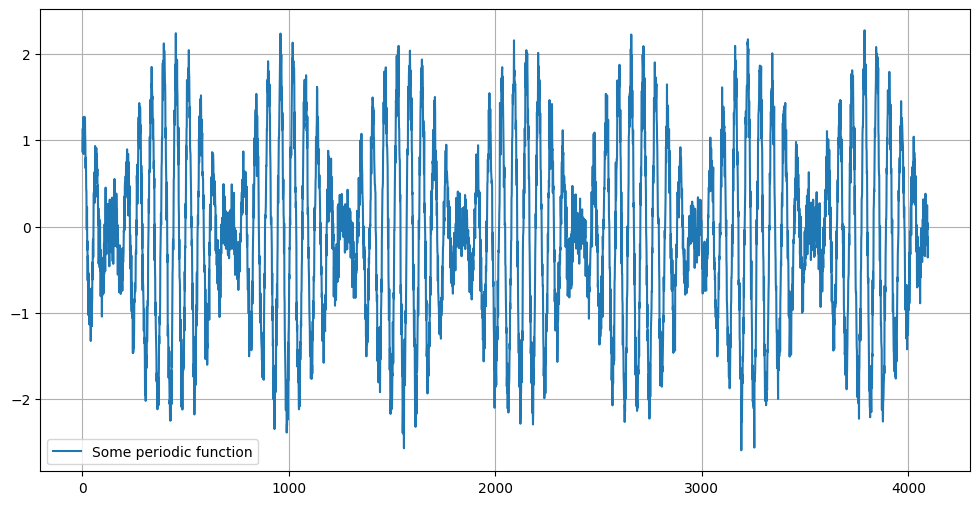

In [ ]:
# Создадим датасет и визуализируем его
training_data = []
for i in range(4096):
    training_data.append(
        np.sin(i / 10) + np.cos(i / 9) + (np.random.randn() - 0.5) / 5 # Sin и Cos + Шумовая компонента
    )

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(training_data, label="Some periodic function")
plt.legend()
plt.grid()
plt.show()

Теперь нужно собрать датасет. Мы будем предсказывать одно будущее наблюдение по окну прошлых наблюдений. Для этого нашу последовательность чисел необходимо нарезать на окна.

In [ ]:
# Функция, чтобы нарезать наши данные на окна  Вход: прошлые наблюдения. Выход: предсказанное будущее наблюдение
def sliding_windows(data, seq_len):
  '''
  data — входные данные
  seq_len — длина каждого кусочка данных (по какому количеству прошлых наблюдений предсказываем будущее)
  '''
  x = [] # Контейнер для последовательностей
  y = [] # Контейнер для целевой переменной

  for i in range(len(data) - seq_len):
      _x = data[i : (i + seq_len)]
      _y = data[i + seq_len]
      x.append(_x)
      y.append(_y)

  return torch.Tensor(np.array(x)), torch.Tensor(np.array(y))

Разделим датасет на две части: обучение и тест.

In [ ]:
# Создаём датасет в удобном формате
seq_len = 8
x, y = sliding_windows(training_data, seq_len)

# Делим его по переменной времени
train_size = int(len(y) * 0.8)

x_train = x[:train_size]
y_train = y[:train_size]

x_test = x[train_size:]
y_test = y[train_size:]

In [ ]:
x_train.shape

torch.Size([3270, 8])

Теперь добавим код для создания датасета и даталоадера.

In [ ]:
class RNNDataset(Dataset):
  def __init__(self, data, targets):

    self.data = data.unsqueeze(-1)
    self.targets = targets

  def __len__(self):
      return len(self.targets)

  def __getitem__(self, idx):
      return self.data[idx], self.targets[idx]

In [ ]:
batch_size = 32
train_ds = RNNDataset(x_train, y_train)
test_ds = RNNDataset(x_test, y_test)

train_dl = DataLoader(train_ds, batch_size=batch_size)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

И не забудем про код для обучения.

In [ ]:
# Функция для одного шага обучения
def train_step(batch, model, loss, optimizer, device):

    model.zero_grad()

    X, y = batch
    X = X.to(device)
    y = y.to(device)

    logits = model(X)
    l = loss(logits, y)

    l.backward()
    optimizer.step()

    return l.item()

In [ ]:
# Функция для обучения на эпохе
def train(model, loss, optimizer, device, train_dataloader):
    model.train()
    train_loss = 0

    for batch in train_dataloader:
      loss_step = train_step(batch, model, loss, optimizer, device)

      # Накапливаем функцию потерь, усредняя её между всеми батчами
      train_loss += loss_step / len(train_dataloader)

    return train_loss

In [ ]:
# Функция для одного шага валидации
def valid_step(batch, model, loss, device):

      X, y = batch
      X = X.to(device)
      y = y.to(device)

      with torch.inference_mode():
        logits = model(X)
        l = loss(logits, y)

      return logits.cpu().numpy(), l.item() # Возвращаем логиты, чтобы можно было нарисовать предсказания модели на графике

In [ ]:
# Функция для всей валидации на эпохе, будем использовать её также для получения предсказаний
def validate(model, loss, device, val_dataloader):
  model.eval()
  val_loss = 0
  preds = []
  for batch in val_dataloader:
    preds_step, loss_step = valid_step(batch, model, loss, device)

    val_loss += loss_step / len(val_dataloader)
    preds.append(preds_step)

  preds = np.concatenate(preds)

  return preds, val_loss

In [ ]:
# Объединяем обучение и валидацию
def train_and_validate(epochs, model, loss, optimizer, device, train_dataloader, val_dataloader, save_every=1, naming=''):

    model.to(device)

    for e in range(epochs):

        train_loss = train(model, loss, optimizer, device, train_dataloader)
        _, val_loss = validate(model, loss, device, val_dataloader)

        print(f'Эпоха: {e} | Train Loss {train_loss} | Val Loss {val_loss}')

        # Хорошая практика - сохранение весов модели каждые n шагов или эпох. Тут мы сохраняем по эпохам
        if e % save_every == 0:
            torch.save(model.state_dict(), f'model_epoch_{e}{naming}.pth')

In [ ]:
# Функция для предсказаний модели
def plot_predictions(model, loss, device, train_dl, test_dl):
  # Воспользуемся функцией validate, чтобы получить предсказания
  train_preds, _ = validate(model, loss, device, train_dl)
  test_preds, _ = validate(model, loss, device, test_dl)
  preds = np.concatenate([train_preds, test_preds])

  # Отрисуем результаты
  plt.figure(figsize=(12, 6))
  plt.plot(training_data, label='True')
  plt.plot(preds, label='Preds')
  plt.axvline(x=train_size, color='red', label='Train|Test split')
  plt.legend()
  plt.grid()
  plt.show()

Теперь тебе предстоит написать свои рекуррентные нейросети, в основе которых лежат RNN, LSTM или GRU.


### Задание 1. RNN [1 балл]
Напиши класс рекуррентной нейросети, в основе которой лежит блок RNN.

#### Твой код

In [ ]:
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size):
    super().__init__()

    self.rnn = nn.RNNCell(input_size, hidden_size)
    self.linear = nn.Linear(hidden_size, 1)# Напиши код здесь

  def forward(self, x):
      h = None
      all_h = [] # Контейнер для промежуточных скрытых состояний
      for i in range(x.shape[1]):  # Итерируемся по размерности времени
          h = self.rnn(x[:, i, :], h) # На каждой итерации RNNCell подаём новый элемент последовательности и прошлое скрытое состояние
          all_h.append(h) # Добавляем новое скрытое состояние в контейнер
      out = self.linear(h)
      return out

Запусти код ниже и проверь, всё ли релизовано правильно. Предсказания должны практически совпадать с ответами.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = RNN(1, 3)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
loss = nn.MSELoss()
epochs = 10

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([6])) that is different to the input size (torch.Size([6, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([18])) that is different to the input size (torch.Size([18, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, t

Эпоха: 0 | Train Loss 1.009236769081609 | Val Loss 1.4579153416248467
Эпоха: 1 | Train Loss 0.9375824483057247 | Val Loss 1.4046382915515168
Эпоха: 2 | Train Loss 0.9336811182568375 | Val Loss 1.3773105666041374
Эпоха: 3 | Train Loss 0.9323239557228044 | Val Loss 1.3587491050935714
Эпоха: 4 | Train Loss 0.9317290971001373 | Val Loss 1.3450225795117707
Эпоха: 5 | Train Loss 0.9314565180430134 | Val Loss 1.334308135108306
Эпоха: 6 | Train Loss 0.9313544382892761 | Val Loss 1.3255827240645888
Эпоха: 7 | Train Loss 0.9313537031773805 | Val Loss 1.3181967990329633
Эпоха: 8 | Train Loss 0.9314193884724552 | Val Loss 1.3117059042247443
Эпоха: 9 | Train Loss 0.931533545038654 | Val Loss 1.3057897850297964


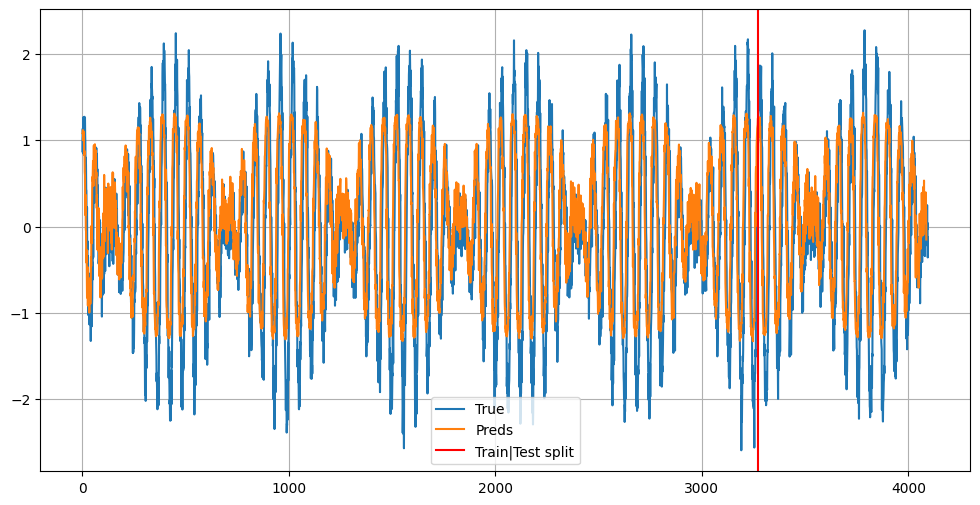

In [ ]:
# Обучение
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl)
# Визуализация предсказаний
plot_predictions(model, loss, device, train_dl, test_dl)

### Задание 2. LSTM [1 балл]
Напиши класс рекуррентной нейросети, в основе которой лежит блок LSTM.

#### Твой код

In [ ]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size
        self.rnn = nn.LSTMCell(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, 1)# Напиши код здесь

    def forward(self, x):
        batch_size = x.size(0)

        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)
        for i in range(x.shape[1]):  # Итерируемся по размерности времени
            h, c = self.rnn(x[:, i, :], (h, c)) # На каждой итерации RNNCell подаём новый элемент последовательности и прошлое скрытое состояние
        out = self.linear(h)
        return out

Запусти код ниже и проверь, всё ли релизовано правильно. Предсказания должны практически совпадать с ответами.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LSTM(1, 3)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
loss = nn.MSELoss()
epochs = 10

Эпоха: 0 | Train Loss 0.9833753166485181 | Val Loss 1.0261239945315397
Эпоха: 1 | Train Loss 0.9532006998880973 | Val Loss 1.0318431673714747
Эпоха: 2 | Train Loss 0.9516895406165171 | Val Loss 1.0312767018778963
Эпоха: 3 | Train Loss 0.9503628729833563 | Val Loss 1.0309546531106413
Эпоха: 4 | Train Loss 0.9492886994865916 | Val Loss 1.0307552500699575
Эпоха: 5 | Train Loss 0.9483808267102084 | Val Loss 1.0306108523733342
Эпоха: 6 | Train Loss 0.947598511262715 | Val Loss 1.0304962206058774
Эпоха: 7 | Train Loss 0.9469178146818306 | Val Loss 1.0303981490433214
Эпоха: 8 | Train Loss 0.9463223598680452 | Val Loss 1.030306669095388
Эпоха: 9 | Train Loss 0.9457996106408172 | Val Loss 1.0302131163099637


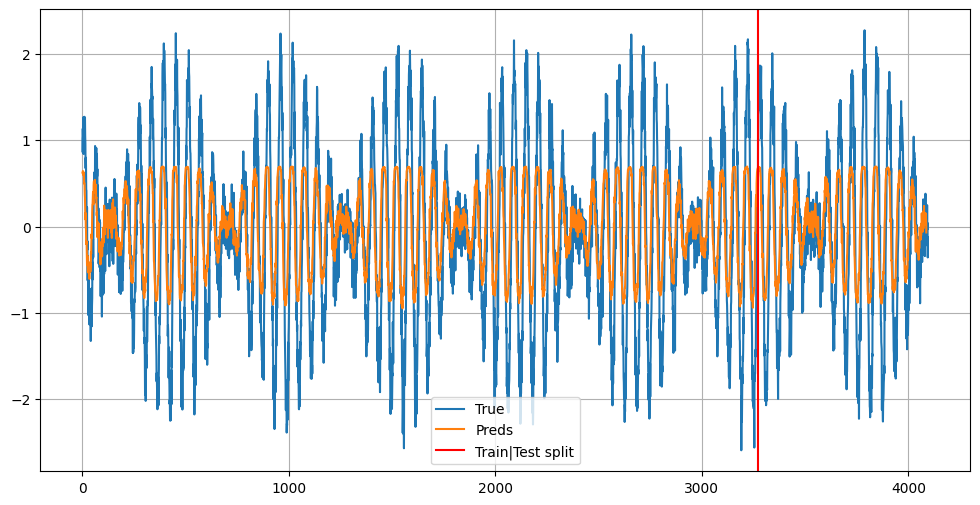

In [ ]:
# Обучение
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl)
# Визуализация предсказаний
plot_predictions(model, loss, device, train_dl, test_dl)

### Задание 3. GRU [1 балл]
Напиши класс рекуррентной нейросети, в основе которой лежит блок GRU.

#### Твой код

In [ ]:
class GRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.hidden_size = hidden_size
        self.rnn = nn.GRUCell(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, 1)# Напиши код здесь

    def forward(self, x):
        batch_size = x.size(0)

        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        for i in range(x.shape[1]):  # Итерируемся по размерности времени
            h = self.rnn(x[:, i, :], h) # На каждой итерации RNNCell подаём новый элемент последовательности и прошлое скрытое состояние
        out = self.linear(h)
        return out

Запусти код ниже и проверь, всё ли релизовано правильно. Предсказания должны практически совпадать с ответами.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = GRU(1, 3)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)
loss = nn.MSELoss()
epochs = 10

Эпоха: 0 | Train Loss 0.9813748100428902 | Val Loss 1.2248800987234483
Эпоха: 1 | Train Loss 0.9462050282333085 | Val Loss 1.1962123988912656
Эпоха: 2 | Train Loss 0.9397087182524132 | Val Loss 1.1839743121885336
Эпоха: 3 | Train Loss 0.9380926547336929 | Val Loss 1.1751018794110188
Эпоха: 4 | Train Loss 0.9375835541382579 | Val Loss 1.1669599631657968
Эпоха: 5 | Train Loss 0.9374592455049742 | Val Loss 1.1592999891592903
Эпоха: 6 | Train Loss 0.9375158383067953 | Val Loss 1.1522288236480493
Эпоха: 7 | Train Loss 0.9376487518904857 | Val Loss 1.1458427456135933
Эпоха: 8 | Train Loss 0.9378011427385712 | Val Loss 1.1401588220435839
Эпоха: 9 | Train Loss 0.9379452219938191 | Val Loss 1.1351407118714771


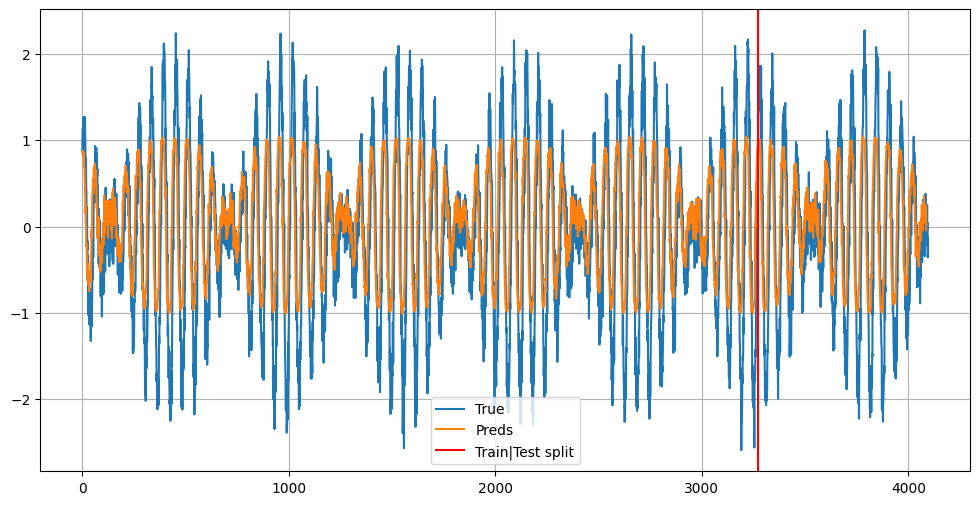

In [ ]:
# Обучение
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl)
# Визуализация предсказаний
plot_predictions(model, loss, device, train_dl, test_dl)

## Часть 2. Сравнение RNN, LSTM и GRU

В предыдущей части задания применялись RNN, LSTM и GRU для предсказания следующего элемента последовательности вещественных чисел. Но, как мы говорили на лекции, рекуррентные нейросети могут решать и другие задачи — например, выполнять классификацию или регрессию для каждого элемента последовательности отдельно (как в задаче PoS-таггинга).

В этой части тебе предстоит решить простую алгоритмическую задачу с помощью разных рекуррентных нейросетей и сравнить скорость и качество их работы в зависимости от длины последовательности.

>**Важно.** До этого использовалось только последнее скрытое состояние рекуррентной нейросети. Теперь тебе предстоит работать с каждым промежуточным состоянием. Все реализации рекуррентных сетей возвращают эти значения, но, возможно, придётся ещё раз заглянуть в документацию.


Рассмотрим постановку задачи.

Каждый пример представляет собой последовательность фиксированной длины, состоящую из цифр из множества {0, 1, 2, 3} и специального символа `?`.

Пример входной последовательности: `1 0 3 2 1 ? 0 2 3 ? 1`.

Символ `?` означает, что в этой позиции нужно восстановить значение, опираясь на предыдущий контекст.

Пусть задано число `k` — количество шагов назад. Для каждой позиции, в которой стоит `?`, модель должна предсказать символ, который находился в последовательности `k` шагов назад.

То есть если `k = 2`, то ответ для входной последовательности будет выглядеть так: `1 0 3 2 1 2 0 2 3 2 1`.

Формально это модификация задачи классификации каждого элемента последовательности. Отличие в том, что необходимо классифицировать не каждый элемент последовательности, а только места с токеном `?`.

Архитектурно нейросеть не меняется, нужно только внести небольшие корректировки в функцию потерь и вычисление метрики.

Вот код для генерации данных для обучения и валидации модели, который генерирует валидные последовательности из описания задания. Можешь разобрать его при желании.

In [ ]:
def generate_copy_k_dataset(
    num_sequences: int, # Размер датасета
    seq_len: int, # Длина последовательностей
    k: int = 5, # Сколько шагов назад был символ для повторения
    p_query: float = 0.2, # Какая доля символов станет "?"
    vocab_size: int = 4, # Размер словаря. То есть сколько будет символов помимо знака "?"
    ignore_index: int = -100, # Индекс для первоначального заполнения вектора правильных ответов.
    seed: int = 123, # Фиксация случайности
):
    """
    Генерация датасета для задачи 'повтори символ через K шагов'
    (гарантируется отсутствие ситуации, когда target — это '?').
    """

    # Фиксация сида и проверки условий на k
    if seed is not None:
        np.random.seed(seed)

    assert k >= 1
    assert k < seq_len

    # Индекс токена, для которого надо предсказать k прошлых значений
    QUESTION_TOKEN = vocab_size  # Индекс '?'

    # Создаём контейнеры для данных
    inputs = np.zeros((num_sequences, seq_len), dtype=np.int64) # Входная последовательность (без "?")
    targets = np.full((num_sequences, seq_len), ignore_index, dtype=np.int64) # Выходная последовательность (с "?")
    mask = np.zeros((num_sequences, seq_len), dtype=bool) # Маска, чтобы обучать модель только на предсказании "?"
    ks = np.zeros(num_sequences, dtype=np.int64) # Какой по счёту элемент назад предсказывать на "?"

    # Итерируемся по количеству последовательностей
    for i in range(num_sequences):

        # Генерируем базовую последовательность, чтобы потом на её основе собирать вход и ответы модели
        base_seq = np.random.randint(0, vocab_size, size=seq_len)

        input_seq = base_seq.copy()
        target_seq = np.full(seq_len, ignore_index, dtype=np.int64) # Позиции ignore_index не участвуют в обучении
        query_positions = np.zeros(seq_len, dtype=bool)

        # Проходим слева направо и решаем, где можно ставить "?"
        for t in range(k, seq_len):

            # Если случайная вероятность меньше p_query, то "затираем" элемент
            if np.random.rand() < p_query:
                # Можно ставить "?", только если позиция t-K не станет "?"
                if not query_positions[t - k]:
                    query_positions[t] = True # Если "?", то True
                    input_seq[t] = QUESTION_TOKEN # Случайный элемент заменяем на индекс "?"
                    target_seq[t] = base_seq[t - k] # Заполняем элемент, который надо предсказывать

        inputs[i] = input_seq
        targets[i] = target_seq
        mask[i] = query_positions

    return inputs, targets, mask

### Задание 1. Универсальный класс модели для различных рекуррентных блоков [2 балла]

В этом задании тебе предстоит написать класс модели, который инициализируется с различными видами рекуррентной нейросети в зависимости от параметра инициализации.

**Что стоит учесть**
- На вход модели подаются индексы, которые соответствуют токенам, а не вещественные числа. То есть в модели должен быть определён [nn.Embedding](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html). Не забудь, что размерность матрицы эмбеддингов больше словаря за счет токена `?`.
- Из RNN нужно забирать промежуточные состояния, так как при финальной классификации нужны будут они все, а не только последнее.
- Все скрытые состояния попадают в финальный линейный слой, который сжимает размерность до количества уникальных токенов.

#### Твой код

In [ ]:
class CopyKModel(nn.Module):
    def __init__(
        self,
        model_type="RNN",  # "RNN", "GRU", "LSTM"
        vocab_size=4,
        embed_dim=32,
        hidden_dim=64,
        num_layers=1,
    ):
        super().__init__()

        self.model_type = model_type
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size + 1, embed_dim)

        if model_type == "RNN":
            self.rnn = nn.RNNCell(embed_dim, hidden_dim)
        elif model_type == "GRU":
            self.rnn = nn.GRUCell(embed_dim, hidden_dim)
        elif model_type == "LSTM":
            self.rnn = nn.LSTMCell(embed_dim, hidden_dim)
        else:
            raise ValueError("Unknown model type")

        self.classifier = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)

        batch_size = x.size(0)
        outputs = []

        if self.model_type == "LSTM":
            h = torch.zeros(batch_size, self.hidden_dim, device=x.device)
            c = torch.zeros(batch_size, self.hidden_dim, device=x.device)

            for i in range(x.shape[1]):
                h, c = self.rnn(x[:, i, :], (h, c))
                logits = self.classifier(h)
                outputs.append(logits)


        else:
            h = torch.zeros(batch_size, self.hidden_dim, device=x.device)

            for i in range(x.shape[1]):
                h = self.rnn(x[:, i, :], h)
                logits = self.classifier(h)
                outputs.append(logits)

        logits = torch.stack(outputs, dim=1)
        return logits

Класс датасета для задачи. Что он возвращает:
1. Последовательность, где некоторые элементы заменены на индекс, соответствующий `?`.
2. Целевую последовательность, где `?` заменён на правильный ответ. Все остальные элементы заменены на значение `ignore_index`, так как они всё равно не попадут в итоговую функцию потерь.
3. Маску, которая соответствует элементам `?`. Она будет использоваться для вычисления метрики.

In [ ]:
class CopyKDataset(Dataset):
    def __init__(
        self,
        num_sequences,
        seq_len,
        k=5,
        p_query=0.2,
        vocab_size=4,
        ignore_index=-100,
        seed=123,
    ):
        self.inputs, self.targets, self.mask = generate_copy_k_dataset(
            num_sequences=num_sequences,
            seq_len=seq_len,
            k=k,
            p_query=p_query,
            vocab_size=vocab_size,
            ignore_index=ignore_index,
            seed=seed,
        )

        self.inputs = torch.LongTensor(self.inputs)
        self.targets = torch.LongTensor(self.targets)
        self.mask = torch.BoolTensor(self.mask)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx], self.mask[idx]

### Задание 2. Функция для вычисления точности (Accuracy) предсказания модели [1 балл]

В этом задании тебе предстоит реализовать функцию для вычисления точности предсказаний, а именно:
1. Извлечь предсказание (индекс класса) из ответов модели.
2. Сравнить предсказания с целевыми метками.
3. Опираясь на маску, выбрать элементы, которые соответствуют `?`.
4. Вычислить среднее.

#### Твой код

In [ ]:
def compute_accuracy(logits, targets, mask):
    preds = logits.argmax(dim=-1)
    preds = preds[mask]
    correct = targets[mask]
    return (preds == correct).float().mean()

### Задание 3. Трансформация ответов модели [1 балл]

В качестве функции потерь будет использоваться [CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html), которая при работе с индексами принимает на вход одномерные массивы для целевой переменной (N) и двумерные массивы для предсказания модели (N, C).

Сейчас у целевой переменной и выхода из модели есть ещё одна размерность длины последовательности. Поэтому для работы функции потерь необходимо привести выход модели и целевую переменную к нужным размерностям.

Сделать это довольно просто. Фактически задача классификации каждого элемента последовательности — это обычная задача классификации, которую провели столько раз, сколько существует элементов последовательности.

То есть необходимо сделать преобразования вида:
1. `[batch_size, seq_len, voc_size] - > [batch_size * seq_len, voc_size]` — для ответов модели.
2. `[batch_size, seq_len] - > [batch_size * seq_len]` — для целевой переменной.

Сделай это в функциях `train_step` и `valid_step`.

В функцию ниже уже добавлено всё необходимое для вычисления accuracy.

#### Твой код

In [ ]:
# Функция для одного шага обучения
def train_step(batch, model, loss, optimizer, device):

    model.zero_grad()

    X, y, mask = batch
    X = X.to(device)
    y = y.to(device)
    mask = mask.to(device)

    logits = model(X)

    B, S, V = logits.size()
    logits = logits.reshape(B * S, V)
    y = y.reshape(B * S)
    mask = mask.reshape(B * S)

    l = loss(logits[mask], y[mask])# Напиши код здесь)

    l.backward()
    optimizer.step()

    return l.item(), compute_accuracy(logits.detach(), y, mask).item()

In [ ]:
# Функция для одного шага валидации
def valid_step(batch, model, loss, device):

      X, y, mask = batch
      X = X.to(device)
      y = y.to(device)
      mask = mask.to(device).bool()

      with torch.inference_mode():
        logits = model(X)

        B, S, V = logits.size()
        logits = logits.reshape(B * S, V)
        y = y.reshape(B * S)
        mask = mask.reshape(B * S)

        l = loss(logits[mask], y[mask])

      return l.item(), compute_accuracy(logits.detach(), y, mask).item()

In [ ]:
# Функция для обучения на эпохе
def train(model, loss, optimizer, device, train_dataloader):
    model.train()
    train_loss = 0
    train_acc = 0
    for batch in train_dataloader:
      loss_step, acc_step = train_step(batch, model, loss, optimizer, device)

      # Накапливаем функцию потерь, усредняя её между всеми батчами
      train_loss += loss_step / len(train_dataloader)
      train_acc += acc_step / len(train_dataloader)

    return train_loss, train_acc

In [ ]:
# Функция для всей валидации на эпохе, которую мы также будем использовать для получения предсказаний
def validate(model, loss, device, val_dataloader):
  model.eval()
  val_loss = 0
  val_acc = 0
  for batch in val_dataloader:
    loss_step, acc_step = valid_step(batch, model, loss, device)

    val_loss += loss_step / len(val_dataloader)
    val_acc += acc_step / len(val_dataloader)

  return val_loss, val_acc

In [ ]:
# Объединяем обучение и валидацию
def train_and_validate(epochs, model, loss, optimizer, device, train_dataloader, val_dataloader, save_every=1, naming=''):

    model.to(device)

    for e in range(epochs):

        train_loss, train_acc = train(model, loss, optimizer, device, train_dataloader)
        val_loss, val_acc = validate(model, loss, device, val_dataloader)

        print(f'Эпоха: {e} | Train Loss {train_loss} | Val Loss {val_loss} | Train Acc {train_acc} | Val Acc {val_acc}')

        # Хорошая практика — сохранение весов модели каждые n шагов или эпох. Тут мы сохраняем по эпохам
        if e % save_every == 0:
            torch.save(model.state_dict(), f'model_epoch_{e}{naming}.pth')

Чтобы упростить проведение дальнейших экспериментов, объединим все созданные функции и классы в одну функцию.

In [ ]:
def run_experiments(num_sequences_train=10000, num_sequences_val=2000, seq_len=100, k=5, seed=123, epochs=5, batch_size=32, lr=1e-3, epochs_rnn=None, epochs_gru=None, epochs_lstm=None, ignore_index=-100):

  # Инициализиация датасетов
  train_dataset = CopyKDataset(
      num_sequences=num_sequences_train,
      seq_len=seq_len,
      k=k,
      seed=seed,
  )

  val_dataset = CopyKDataset(
      num_sequences=num_sequences_val,
      seq_len=seq_len,
      k=k,
      seed=seed,
  )

  # Инициализиация даталоадеров
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size=batch_size)

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Функция потерь, которая будет игнорировать индексы, для которых значение = ignore_index. То есть считаем только по индексам, которые соответствуют "?"
  loss_fn = nn.CrossEntropyLoss(ignore_index=ignore_index)

  # Контейнер для моделей
  models = {
      "RNN": (CopyKModel("RNN"), epochs_rnn if epochs_rnn else epochs),
      "GRU": (CopyKModel("GRU"), epochs_gru if epochs_gru else epochs),
      "LSTM": (CopyKModel("LSTM"), epochs_lstm if epochs_lstm else epochs),
  }

  # Контейнер для мониторинга времени
  times = {'RNN': None,
           'GRU': None,
           'LSTM': None}

  for name, (model, epochs) in models.items():

      print(f"\n==== Training {name} ====")

      optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

      start = time()

      train_and_validate(
          epochs=epochs,
          model=model,
          loss=loss_fn,
          optimizer=optimizer,
          device=device,
          train_dataloader=train_loader,
          val_dataloader=val_loader,
          naming=f"_{name}",
      )

      stop = time()
      # Среднее время на одну эпоху
      times[name] = round((stop - start)/epochs, 2)
  print(times)

### Задание 4. Эксперименты [2 балла]

В этом задании тебе необходимо показать, как изменяется качество работы различных рекуррентных нейросетей в зависимости от расстояния до элемента, который нужно было запомнить.

Тебе предстоит провести минимум три эксперимента, в которых:
1. RNN, GRU, LSTM качественно решают задачу (0,66 балла).
2. RNN уже не обучается, а GRU и LSTM как-то справляются с задачей (0,66 балла).
3. Учится только LSTM (0,67 балла).

Не обязательно учить модели, пока они не начнут решать задачу идеально. Главное — чтобы качество стало лучше случайного уровня (0,25). Например, 0,26 уже будет достаточно.

Качество работы моделей можно варьировать параметром `k` из функции выше. Он отвечает за то, насколько «старый» индекс надо вернуть для текущего `?`. То есть если `k=5`, то для `?` нужно вернуть индекс, который был в последовательности пять шагов назад.

Возможно, тебе придётся изменить и другие параметры. Среди незнакомых тебе:
* `num_sequences_train` — размер обучающей выборки;
* `num_sequences_val` — размер валидационной выборки;
* `seq_len` — длина генерируемой последовательности;
* `epochs_*` — группа параметров, отвечающих за количество эпох для разных моделей. Ты можешь его использовать, например, после второго эксперимента, где видно, что GRU и LSTM ещё учатся, а RNN — уже нет. Тогда нет смысла ждать большое количество эпох в третьем эксперименте, где `k` будет ещё больше.

Помимо логов в конце обучения выводится время работы модели на одной эпохе. Оно пригодится тебе для ответов на вопросы после эксперимента.

#### Твой код

In [ ]:
# RNN, GRU, LSTM работают примерно одинаково хорошо
run_experiments(k = 5, epochs=2)


==== Training RNN ====
Эпоха: 0 | Train Loss 0.3587874013204546 | Val Loss 0.016756199728993195 | Train Acc 0.8754059455741363 | Val Acc 0.9999999914850493
Эпоха: 1 | Train Loss 0.00892412640487615 | Val Loss 0.004792813322551195 | Train Acc 0.9999872634586093 | Val Acc 0.9999999914850493

==== Training GRU ====
Эпоха: 0 | Train Loss 0.8001284092759937 | Val Loss 0.37893782579709606 | Train Acc 0.6357479256372482 | Val Acc 0.8527163238752455
Эпоха: 1 | Train Loss 0.17738514952956683 | Val Loss 0.06180042832616775 | Train Acc 0.9434075606897616 | Val Acc 0.9863477945327755

==== Training LSTM ====
Эпоха: 0 | Train Loss 0.8186933502031208 | Val Loss 0.38820377938331113 | Train Acc 0.6249858211404596 | Val Acc 0.8510761762422228
Эпоха: 1 | Train Loss 0.1897414681343985 | Val Loss 0.07800230508049329 | Train Acc 0.9418645265003365 | Val Acc 0.9840246987721274
{'RNN': 18.04, 'GRU': 16.72, 'LSTM': 16.68}


In [ ]:
# RNN ломается, а GRU и LSTM ещё работают
run_experiments(k = 15, epochs_rnn=2, epochs_gru=2, epochs=5)


==== Training RNN ====
Эпоха: 0 | Train Loss 1.3884034073010039 | Val Loss 1.388694305268545 | Train Acc 0.2484717243871748 | Val Acc 0.249900076597456
Эпоха: 1 | Train Loss 1.3874370053934226 | Val Loss 1.3869686845749145 | Train Acc 0.24949334676082915 | Val Acc 0.25045477823605605

==== Training GRU ====
Эпоха: 0 | Train Loss 1.344048965091523 | Val Loss 1.215338180935572 | Train Acc 0.3117580337646292 | Val Acc 0.44602161220141817
Эпоха: 1 | Train Loss 1.1159687773488194 | Val Loss 1.0432367135608005 | Train Acc 0.4903947669096268 | Val Acc 0.522615703325423

==== Training LSTM ====
Эпоха: 0 | Train Loss 1.3547725170945966 | Val Loss 1.25706592627934 | Train Acc 0.30134808298307475 | Val Acc 0.40439276988544176
Эпоха: 1 | Train Loss 1.1520948505249262 | Val Loss 1.0513616563781862 | Train Acc 0.4689940972069197 | Val Acc 0.5219296207503666
Эпоха: 2 | Train Loss 0.9818193105082161 | Val Loss 0.9107861963529434 | Train Acc 0.5516249531755049 | Val Acc 0.5799488027890523
Эпоха: 3 | T

In [ ]:
# RNN и GRU ломается, а LSTM ещё работает
run_experiments(k = 15, seq_len = 200, epochs_rnn=1, epochs_gru=1, epochs_lstm=5, num_sequences_train=2000, num_sequences_val=400)


==== Training RNN ====
Эпоха: 0 | Train Loss 1.3884355851582115 | Val Loss 1.386092497752263 | Train Acc 0.2509892221008028 | Val Acc 0.25959575978609234

==== Training GRU ====
Эпоха: 0 | Train Loss 1.3873390489154396 | Val Loss 1.3870031558550322 | Train Acc 0.25377189214267426 | Val Acc 0.2545307267170686

==== Training LSTM ====
Эпоха: 0 | Train Loss 1.3866559891473682 | Val Loss 1.3861050330675562 | Train Acc 0.2535478583877049 | Val Acc 0.25816823083620805
Эпоха: 1 | Train Loss 1.365747088477725 | Val Loss 1.3370011311310988 | Train Acc 0.3022062745359208 | Val Acc 0.33808810435808617
Эпоха: 2 | Train Loss 1.314525288248819 | Val Loss 1.2831373123022225 | Train Acc 0.35546482981197414 | Val Acc 0.3811474602956038
Эпоха: 3 | Train Loss 1.2568797743509685 | Val Loss 1.220075900738056 | Train Acc 0.4052505568852499 | Val Acc 0.43914215381328875
Эпоха: 4 | Train Loss 1.1834226316875878 | Val Loss 1.1398799969599798 | Train Acc 0.46018235645596955 | Val Acc 0.48358685465959406
{'RNN'

### Вопрос 1 [0,5 балла]

Почему у GRU и LSTM больше параметров, чем у RNN, в три или четыре раза соответственно, но скорость обучения и работы больше не в три или четыре раза? Возможно, у тебя получилось так, что скорость практически не отличается.

Вычисление 1 или 3 матриц - без разницы, так как вычисления хорошо и просто параллелятся на гпу. Основная проблема в том что нужно дождаться вычислений, а сколько их, уже не так важно

### Вопрос 2 [0,5 балла]

Есть ли у моделей отличия, связанные со скоростью падения значения функции потерь? С чем такие отличия могут быть связаны?

Да, что видно по экспериментам. RNN быстро теряет информацию за счет того, что она легковесная и соответственно хранит меньше данных, чем обычно. GRU хранит больше данных, за счет чего чуть быстрее обучается, но все равно в итоге по точности на длинной дистанции проиграет LSTM, который хранит максимум данных.